# Convergence and 1D benchmark

This notebook checks numerical trust in two ways:
- grid refinement errors,
- 1D analytic benchmark errors.


## Setup


In [7]:
import numpy as np
import matplotlib.pyplot as plt

from skin_diffusion.notebook_helpers import setup_repo_root, run_module, load_json, assert_paths_exist

repo_root = setup_repo_root()
print('repo_root:', repo_root)


repo_root: C:\Users\nwals\Documents\COMP3931_IndividualProject


## Run benchmark scripts


In [8]:
# run grid refinement benchmark
run_module('scripts.sim.benchmark_v1', ['--config', 'configs/sim/v1_baseline.yaml'], repo_root=repo_root)

# run 1D analytic benchmark
run_module('scripts.sim.benchmark_v1_1d', ['--config', 'configs/sim/v1_baseline.yaml'], repo_root=repo_root)

report_path = 'outputs/sim/v1/benchmark/report.json'
report_1d_path = 'outputs/sim/v1/benchmark/report_1d.json'
assert_paths_exist([report_path, report_1d_path])

report = load_json(report_path)
report_1d = load_json(report_1d_path)


running: c:\Users\nwals\Documents\COMP3931_IndividualProject\.venv\Scripts\python.exe -m scripts.sim.benchmark_v1 --config configs/sim/v1_baseline.yaml
running: c:\Users\nwals\Documents\COMP3931_IndividualProject\.venv\Scripts\python.exe -m scripts.sim.benchmark_v1_1d --config configs/sim/v1_baseline.yaml


## Convergence curves

Lower error for finer grid pairs is what we want.


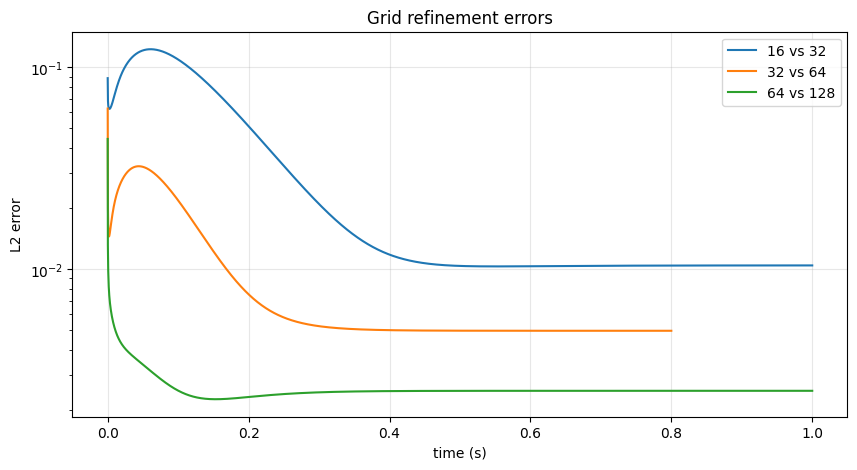

summary: {'16_vs_32': {'mean': 0.029851783637035296, 'final': 0.010443718631572493, 'max': 0.12295470382822694}, '32_vs_64': {'mean': 0.008936896744664058, 'final': 0.004956370969118494, 'max': 0.0625}, '64_vs_128': {'mean': 0.0025984153289432778, 'final': 0.0024993219798361693, 'max': 0.04419417382415922}}


In [9]:
plt.figure(figsize=(10, 5))
plt.plot(report['t_save_16'], report['errors_16_vs_32'], label='16 vs 32')
plt.plot(report['t_save_32'], report['errors_32_vs_64'], label='32 vs 64')
plt.plot(report['t_save_64'], report['errors_64_vs_128'], label='64 vs 128')
plt.yscale('log')
plt.xlabel('time (s)')
plt.ylabel('L2 error')
plt.title('Grid refinement errors')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('summary:', report['summary'])


## 1D analytic errors

This prints the 1D benchmark errors directly from report JSON.


In [10]:
times = report_1d['times']
errors = np.array(report_1d['errors'], dtype=float)

print('1D analytic benchmark errors')
print('-' * 40)

for i in range(len(times)):
    t = times[i]
    e = errors[i]
    print(f't={t:.3f}s -> L2 error={e:.3e}')

print('max error :', float(np.max(errors)))
print('mean error:', float(np.mean(errors)))

if float(np.max(errors)) < 1e-6:
    print('verdict   : very small error, strong agreement with analytic solution')
else:
    print('verdict   : error is larger than expected, review setup')


1D analytic benchmark errors
----------------------------------------
t=0.000s -> L2 error=0.000e+00
t=0.500s -> L2 error=2.659e-09
t=1.000s -> L2 error=1.664e-14
max error : 2.659040778042563e-09
mean error: 8.863524717743003e-10
verdict   : very small error, strong agreement with analytic solution
